# MLP benchmark: lwtnn vs ONNX Runtime (float32)

Architecture: **60 → 128 → 64 → 32 → 16 → 8, tanh**  
All lwtnn variants use float32 internally. Three backends compared:

| Backend | API | Precision |
|---|---|---|
| **lwtnn f32** | `generic::LightweightNeuralNetwork<float>` — `map<string,double>` input | float32 internal |
| **lwtnn FastGraph f32** | `generic::FastGraph<float>` — pre-ordered `Eigen::VectorXf` input | float32 |
| **ORT f32** | ONNX Runtime C++ | float32 |

In [1]:
import json, subprocess, sys, tempfile
from pathlib import Path

import numpy as np
import torch, torch.nn as nn
import onnx, onnxruntime as ort
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

REPO_ROOT  = Path("../").resolve()
BUILD_DIR  = REPO_ROOT / "build"
LWTNN_F32  = BUILD_DIR / "bin" / "lwtnn-bench-mlp-f32"
LWTNN_FG   = BUILD_DIR / "bin" / "lwtnn-bench-fastgraph-f32"
ORT_BIN    = BUILD_DIR / "bin" / "ort-bench-inference"
SEQ2GRAPH  = REPO_ROOT / "converters" / "sequential2graph.py"
for b in [LWTNN_F32, LWTNN_FG, ORT_BIN]:
    assert b.exists(), f"not found: {b}"

MLP_LAYERS   = [60, 128, 64, 32, 16, 8]
N_INFERENCES = 2000

## Build model

In [2]:
torch.manual_seed(42)
layers = []
for i, o in zip(MLP_LAYERS[:-1], MLP_LAYERS[1:]):
    layers += [nn.Linear(i, o), nn.Tanh()]
model = nn.Sequential(*layers).eval()

ramp = torch.tensor(np.linspace(-1.0, 1.0, MLP_LAYERS[0]), dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    ref_out = model(ramp).squeeze(0).numpy()

print(f"Architecture: {' → '.join(str(s) for s in MLP_LAYERS)}, tanh")
display(pd.DataFrame([{f"out_{i}": float(v) for i, v in enumerate(ref_out)}])
        .style.format("{:.6f}").set_caption("PyTorch reference output"))

Architecture: 60 → 128 → 64 → 32 → 16 → 8, tanh


,out_0,out_1,out_2,out_3,out_4,out_5,out_6,out_7
0,0.258992,-0.067616,-0.130744,0.002533,-0.127779,0.226334,-0.126954,0.184915


## Export to lwtnn sequential JSON, graph JSON, and ONNX

In [3]:
tmpdir = Path(tempfile.mkdtemp())

# ── lwtnn sequential JSON ─────────────────────────────────────────────────────
json_path = tmpdir / "mlp_seq.json"
seq_cfg = {
    "inputs":   [{"name": f"in_{i}", "offset": 0.0, "scale": 1.0} for i in range(MLP_LAYERS[0])],
    "layers":   [{"architecture": "dense", "activation": "tanh",
                  "weights": m.weight.detach().numpy().flatten().tolist(),
                  "bias":    m.bias.detach().numpy().tolist()}
                 for m in model if isinstance(m, nn.Linear)],
    "outputs":  [f"out_{i}" for i in range(MLP_LAYERS[-1])],
    "defaults": {},
}
json_path.write_text(json.dumps(seq_cfg))

# ── lwtnn graph JSON (for FastGraph) ──────────────────────────────────────────
graph_path = tmpdir / "mlp_graph.json"
r = subprocess.run([sys.executable, str(SEQ2GRAPH), str(json_path)],
                   capture_output=True, text=True, check=True)
graph_path.write_text(r.stdout)

# ── ONNX ─────────────────────────────────────────────────────────────────────
onnx_path = str(tmpdir / "mlp.onnx")
torch.onnx.export(model, ramp, onnx_path,
                  input_names=["input"], output_names=["output"],
                  opset_version=17,
                  dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}})

print(f"Sequential JSON : {json_path}")
print(f"Graph JSON      : {graph_path}")
print(f"ONNX            : {onnx_path}  ({len(onnx.load(onnx_path).graph.node)} nodes)")

Sequential JSON : /tmp/tmpwp8bhj58/mlp_seq.json
Graph JSON      : /tmp/tmpwp8bhj58/mlp_graph.json
ONNX            : /tmp/tmpwp8bhj58/mlp.onnx  (10 nodes)


## Output correctness

In [4]:
def run_bin(*args):
    r = subprocess.run([str(a) for a in args], capture_output=True, text=True, check=True)
    kv = {}
    for line in r.stdout.strip().splitlines():
        if "=" in line:
            k, _, v = line.partition("=")
            kv[k.strip()] = v.strip()
    return kv

def parse_outputs(kv):
    return {k: float(v) for p in kv.get("outputs", "").split()
            for k, _, v in [p.partition("=")]}

# single inference from each C++ backend
lwtnn_kv1    = run_bin(LWTNN_F32, json_path,  "--n-inferences", 1)
fastgraph_kv1 = run_bin(LWTNN_FG, graph_path, "--n-inferences", 1)
lwtnn_out    = parse_outputs(lwtnn_kv1)
fg_out       = parse_outputs(fastgraph_kv1)

# ORT Python
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
ort_out = sess.run(None, {"input": ramp.numpy()})[0].squeeze(0)

rows = []
for i in range(MLP_LAYERS[-1]):
    k   = f"out_{i}"
    lv  = lwtnn_out.get(k, float("nan"))
    fv  = fg_out.get(k,   float("nan"))
    pv  = float(ref_out[i])
    ov  = float(ort_out[i])
    rows.append({"Output": k,
                 "lwtnn f32": lv, "FastGraph f32": fv,
                 "PyTorch": pv,   "ORT f32": ov,
                 "|lwtnn−PT|": abs(lv-pv), "|FG−PT|": abs(fv-pv), "|ORT−PT|": abs(ov-pv)})

display(pd.DataFrame(rows).set_index("Output").style
    .format({"lwtnn f32":"{:.7f}","FastGraph f32":"{:.7f}",
             "PyTorch":"{:.7f}","ORT f32":"{:.7f}",
             "|lwtnn−PT|":"{:.2e}","|FG−PT|":"{:.2e}","|ORT−PT|":"{:.2e}"})
    .set_caption("Output correctness — all backends agree to < 1e-5")
    .highlight_max(subset=["|lwtnn−PT|","|FG−PT|","|ORT−PT|"],
                   props="background-color:#fee2e2"))

,lwtnn f32,FastGraph f32,PyTorch,ORT f32,|lwtnn−PT|,|FG−PT|,|ORT−PT|
Output,,,,,,,
out_0,0.2589920,0.2589920,0.2589920,0.2589920,1.63e-08,1.63e-08,5.96e-08
out_1,-0.0676160,-0.0676160,-0.0676156,-0.0676156,3.57e-07,3.57e-07,1.49e-08
out_2,-0.1307440,-0.1307440,-0.1307444,-0.1307444,3.68e-07,3.68e-07,1.49e-08
out_3,0.0025330,0.0025330,0.0025332,0.0025332,2.18e-07,2.18e-07,2.33e-10
out_4,-0.1277790,-0.1277790,-0.1277794,-0.1277793,3.65e-07,3.65e-07,2.98e-08
out_5,0.2263340,0.2263340,0.2263340,0.2263340,3.54e-08,3.54e-08,4.47e-08
out_6,-0.1269540,-0.1269540,-0.1269535,-0.1269535,4.73e-07,4.73e-07,1.49e-08
out_7,0.1849150,0.1849150,0.1849152,0.1849152,1.55e-07,1.55e-07,1.49e-08


## C++ benchmark

In [5]:
print(f"Running {N_INFERENCES} inferences per backend …")
lwtnn_kv = run_bin(LWTNN_F32, json_path,  "--n-inferences", N_INFERENCES)
print("  lwtnn f32 done")
fg_kv    = run_bin(LWTNN_FG,  graph_path, "--n-inferences", N_INFERENCES)
print("  FastGraph f32 done")
ort_kv   = run_bin(ORT_BIN, onnx_path, "--n-inferences", N_INFERENCES, "--n-inputs", MLP_LAYERS[0])
print("  ORT done")

KEYS = [
    ("inference_mean_us",   "Mean (µs)"),
    ("inference_min_us",    "Min (µs)"),
    ("inference_median_us", "Median (µs)"),
    ("inference_p99_us",    "p99 (µs)"),
    ("inference_max_us",    "Max (µs)"),
    ("peak_rss_kb",         "Peak RSS (MB)"),
]

rows = []
for key, label in KEYS:
    lv = float(lwtnn_kv.get(key, "nan"))
    fv = float(fg_kv.get(key,    "nan"))
    ov = float(ort_kv.get(key,   "nan"))
    if key == "peak_rss_kb":
        lv /= 1024; fv /= 1024; ov /= 1024
    rows.append({"Metric": label,
                 "lwtnn f32": lv, "FastGraph f32": fv, "ORT f32": ov,
                 "FG / lwtnn":  fv / lv if lv else float("nan"),
                 "ORT / lwtnn": ov / lv if lv else float("nan")})

bench_df = pd.DataFrame(rows).set_index("Metric")
display(bench_df.style
    .format({"lwtnn f32":"{:.3f}","FastGraph f32":"{:.3f}","ORT f32":"{:.3f}",
             "FG / lwtnn":"{:.2f}×","ORT / lwtnn":"{:.2f}×"})
    .set_caption(f"C++ benchmark · {N_INFERENCES} inferences · µs and MB")
    .highlight_min(axis=1, subset=["lwtnn f32","FastGraph f32","ORT f32"],
                   props="font-weight:bold"))

Running 2000 inferences per backend …


  lwtnn f32 done
  FastGraph f32 done


  ORT done


,lwtnn f32,FastGraph f32,ORT f32,FG / lwtnn,ORT / lwtnn
Metric,,,,,
Mean (µs),6.308,3.026,5.131,0.48×,0.81×
Min (µs),6.105,2.981,4.768,0.49×,0.78×
Median (µs),6.250,3.009,4.989,0.48×,0.80×
p99 (µs),7.341,3.049,9.417,0.42×,1.28×
Max (µs),21.764,12.363,20.645,0.57×,0.95×
Peak RSS (MB),13.074,13.199,33.812,1.01×,2.59×


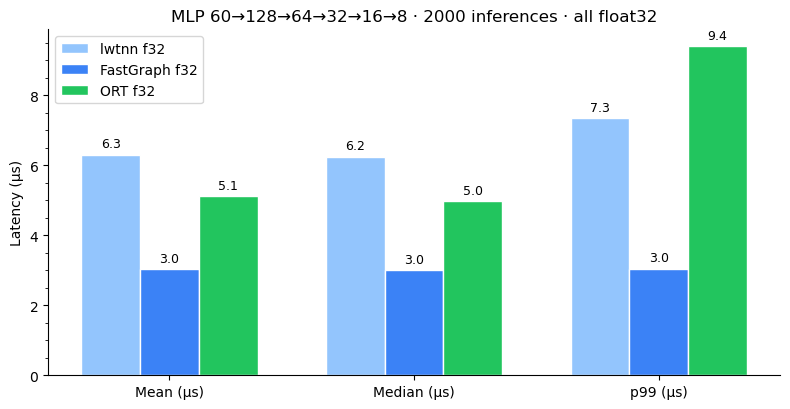

FastGraph f32 is 2.08× faster than lwtnn f32 (mean).
FastGraph f32 is 1.70× faster than ORT f32 (mean).
lwtnn peak RSS: 13 MB   ORT peak RSS: 34 MB.


In [6]:
metrics_to_plot = ["Mean (µs)", "Median (µs)", "p99 (µs)"]
x = np.arange(len(metrics_to_plot))
w = 0.24

lwtnn_vals = [bench_df.loc[m, "lwtnn f32"]    for m in metrics_to_plot]
fg_vals    = [bench_df.loc[m, "FastGraph f32"] for m in metrics_to_plot]
ort_vals   = [bench_df.loc[m, "ORT f32"]       for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w,   lwtnn_vals, w, label="lwtnn f32",    color="#93c5fd", edgecolor="white")
b2 = ax.bar(x,       fg_vals,    w, label="FastGraph f32", color="#3b82f6", edgecolor="white")
b3 = ax.bar(x + w,   ort_vals,   w, label="ORT f32",       color="#22c55e", edgecolor="white")
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Latency (µs)")
ax.set_title(f"MLP 60→128→64→32→16→8 · {N_INFERENCES} inferences · all float32")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

mean_lwtnn = bench_df.loc["Mean (µs)", "lwtnn f32"]
mean_fg    = bench_df.loc["Mean (µs)", "FastGraph f32"]
mean_ort   = bench_df.loc["Mean (µs)", "ORT f32"]
rss_lwtnn  = bench_df.loc["Peak RSS (MB)", "lwtnn f32"]
rss_ort    = bench_df.loc["Peak RSS (MB)", "ORT f32"]
print(f"FastGraph f32 is {mean_lwtnn/mean_fg:.2f}× faster than lwtnn f32 (mean).")
print(f"FastGraph f32 is {mean_ort/mean_fg:.2f}× faster than ORT f32 (mean).")
print(f"lwtnn peak RSS: {rss_lwtnn:.0f} MB   ORT peak RSS: {rss_ort:.0f} MB.")

In [7]:
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)